<div style="color: #0B39C9; font-size: 24px; font-weight: 700;">

DỰ ÁN: XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

</div>

# <span style="color: #E60000;">Notebook 06.1. Threshold Optimization</span>

*Tối ưu ngưỡng dự đoán cho HistGradientBoosting bằng tập Validation trước khi đánh giá cuối cùng trên tập Test*

---
**Input:** Bảng `application_features` trong PostgreSQL và cấu hình HistGradientBoosting đã chốt tại Notebook 06.

**Output:** Mô hình HistGradientBoosting, ngưỡng dự đoán được chọn từ Validation và bộ metric đánh giá cuối cùng trên Test.

**Pipeline:** Feature Engineering → Machine Learning → **Threshold Optimization** → Prediction Demo


## I. Giới thiệu


### 1. Mục tiêu của Notebook 06.1


Notebook này tìm ngưỡng giúp cân bằng Precision và Recall của HistGradientBoosting. Ngưỡng được chọn trên Validation trước khi đánh giá một lần trên Test.


### 2. Vai trò của ngưỡng dự đoán


Ngưỡng `0,5` chỉ là giá trị mặc định. Hạ ngưỡng thường làm Recall tăng, còn tăng ngưỡng thường làm Precision tăng; F1-score được dùng để tìm điểm cân bằng.


### 3. Mạch liên kết: Notebook 06 → Notebook 06.1 → Notebook 07


Notebook 06 chọn HistGradientBoosting, Notebook 06.1 chọn ngưỡng dự đoán và Notebook 07 sử dụng mô hình cùng ngưỡng cuối.


## II. Đọc dữ liệu


### 1. Chuẩn bị thư viện và kết nối PostgreSQL


Đoạn code bên dưới import thư viện và tạo kết nối PostgreSQL từ file `.env`.


In [1]:
import os
import pandas as pd

from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.model_selection import train_test_split

# Tìm file .env từ thư mục hiện tại hoặc thư mục cha.
env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
if not env_path.exists():
    raise FileNotFoundError("Không tìm thấy file .env.")

load_dotenv(env_path)
db_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER", "postgres"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST", "localhost"),
    port=int(os.getenv("DB_PORT", "5432")),
    database=os.getenv("DB_NAME", "credit_risk_db"),
)
engine = create_engine(db_url)


### 2. Đọc bảng `application_features`


Đoạn code bên dưới đọc bảng `application_features` và hiển thị 5 dòng đầu.


In [2]:
# Đọc dữ liệu đã tạo tại Notebook 05.
df = pd.read_sql("SELECT * FROM public.application_features", engine)

assert {"sk_id_curr", "target"}.issubset(df.columns), (
    "Dữ liệu phải có sk_id_curr và target."
)

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng × {df.shape[1]:,} cột")
display(df.head())


Kích thước dữ liệu: 306,195 dòng × 234 cột


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,credit_card_balance_to_income,has_pos_cash_dpd,pos_cash_history_months,age_income_interaction,late_debt_interaction,ext_ltv_interaction,ext_credit_income_interaction,ext_dti_interaction,ext_min_ltv_interaction,ext_bureau_debt_interaction
0,112760,0,Cash loans,F,N,Y,0.0,135000.0,450000.0,24543.0,...,NaN,0,11.0,35-44 | Thấp,Không ghi nhận trễ | Thấp,0.705723,2.352409,0.128300,0.978805,0.175144
1,112761,0,Revolving loans,M,N,Y,0.0,193500.0,450000.0,22500.0,...,NaN,0,12.0,35-44 | Cao,Không ghi nhận trễ | Trung bình,0.450933,1.048681,0.052434,0.497122,0.119399
2,112762,0,Cash loans,F,N,Y,0.0,225000.0,781920.0,40486.5,...,NaN,0,NaN,25-34 | Cao,Không ghi nhận trễ | Cao,0.512698,1.538094,0.079640,0.677262,0.065402
3,112763,0,Cash loans,F,N,Y,0.0,72000.0,545040.0,20677.5,...,NaN,0,7.0,55+ | Rất thấp,Không ghi nhận trễ | Thấp,0.568609,3.553809,0.134823,0.671736,0.234200
4,112764,0,Cash loans,F,Y,Y,0.0,225000.0,742500.0,69421.5,...,NaN,0,5.0,55+ | Cao,NaN,0.374557,1.236037,0.115566,0.494002,NaN


### 3. Kiểm tra dữ liệu đầu vào


Đoạn code bên dưới tóm tắt quy mô, missing và phân bố target của dữ liệu đầu vào.


In [3]:
# Tạo bảng kiểm tra ngắn gọn.
input_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng", "Số cột", "Số khách hàng",
        "Số dòng trùng", "Tổng giá trị thiếu",
        "Tỷ lệ thiếu (%)", "Tỷ lệ target = 1 (%)",
    ],
    "Kết quả": [
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        f"{df['sk_id_curr'].nunique():,}",
        f"{df.duplicated().sum():,}",
        f"{df.isna().sum().sum():,}",
        f"{df.isna().sum().sum() / df.size * 100:.2f}",
        f"{df['target'].mean() * 100:.2f}",
    ],
})

display(input_summary)


,Chỉ tiêu,Kết quả
0,Số dòng,"306,195"
1,Số cột,234
2,Số khách hàng,"306,195"
3,Số dòng trùng,0
4,Tổng giá trị thiếu,"4,609,044"
5,Tỷ lệ thiếu (%),6.43
6,Tỷ lệ target = 1 (%),8.09


### 4. Xác định Feature và Target


Đoạn code bên dưới tạo Feature và Target, đồng thời loại hai interaction cần tạo lại từ Train.


In [4]:
ID_COLUMN = "sk_id_curr"
TARGET_COLUMN = "target"

# Tách Feature và Target.
X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

# Hai interaction dùng phân vị sẽ được tạo lại từ Train.
INTERACTION_HOC_LAI = [
    "age_income_interaction",
    "late_debt_interaction",
]
interaction_co_san = [col for col in INTERACTION_HOC_LAI if col in X.columns]
X = X.drop(columns=interaction_co_san)

assert ID_COLUMN not in X.columns
assert TARGET_COLUMN not in X.columns
assert len(X) == len(y)

print(f"Số Feature ban đầu: {X.shape[1]:,}")
print("Interaction sẽ tạo lại:", interaction_co_san)


Số Feature ban đầu: 230
Interaction sẽ tạo lại: ['age_income_interaction', 'late_debt_interaction']


## III. Chia tập Train, Validation và Test


### 1. Tách tập Test


Đoạn code bên dưới giữ riêng 20% dữ liệu làm tập Test.


In [5]:
# Tách Test trước để không dùng khi chọn ngưỡng.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


### 2. Tách tập Train và Validation


Đoạn code bên dưới chia phần còn lại thành Train và Validation.


In [6]:
# Validation chiếm 20% của phần Train + Validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val,
)


### 3. Kiểm tra phân bố Target


Đoạn code bên dưới kiểm tra quy mô và tỷ lệ nợ xấu của ba tập dữ liệu.


In [7]:
# Kiểm tra ba tập không trùng nhau và giữ cùng danh sách cột.
assert len(X_train) + len(X_val) + len(X_test) == len(X)
assert X_train.index.intersection(X_val.index).empty
assert X_train.index.intersection(X_test.index).empty
assert X_val.index.intersection(X_test.index).empty
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns)

# Tóm tắt kết quả chia dữ liệu.
split_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation", "Test"],
    "Số dòng": [len(X_train), len(X_val), len(X_test)],
    "Tỷ trọng (%)": [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100,
    ],
    "Tỷ lệ target = 1 (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100,
    ],
})

display(split_summary.round(2))


,Tập dữ liệu,Số dòng,Tỷ trọng (%),Tỷ lệ target = 1 (%)
0,Train,195964,64.0,8.09
1,Validation,48992,16.0,8.09
2,Test,61239,20.0,8.09


## IV. Chuẩn bị dữ liệu


### 1. Xác định cột số và cột phân loại


Đoạn code bên dưới xác định kiểu cột từ tập Train.


In [8]:
# Chỉ dùng Train để xác định kiểu cột.
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(exclude="number").columns

print(f"Cột số: {len(num_cols):,}")
print(f"Cột phân loại: {len(cat_cols):,}")


Cột số: 213
Cột phân loại: 17


### 2. Xử lý giá trị thiếu


Đoạn code bên dưới dùng median của Train cho cột số và nhãn `Unknown` cho cột phân loại.


In [9]:
# Median chỉ được tính từ Train.
train_median = X_train[num_cols].median()

for data in [X_train, X_val, X_test]:
    data[num_cols] = data[num_cols].fillna(train_median)
    data[cat_cols] = data[cat_cols].astype("string").fillna("Unknown")


### 3. Mã hóa và kiểm tra dữ liệu


Đoạn code bên dưới mã hóa Train trước, sau đó căn chỉnh Validation và Test theo cùng danh sách cột.


In [10]:
import numpy as np

# Mã hóa cột phân loại thành các cột 0/1.
X_train_hgb = pd.get_dummies(X_train, columns=cat_cols, dtype=int)
X_val_hgb = pd.get_dummies(X_val, columns=cat_cols, dtype=int).reindex(
    columns=X_train_hgb.columns, fill_value=0
)
X_test_hgb = pd.get_dummies(X_test, columns=cat_cols, dtype=int).reindex(
    columns=X_train_hgb.columns, fill_value=0
)
FEATURE_NAMES = X_train_hgb.columns.tolist()

# Kiểm tra ba tập trước khi huấn luyện.
for data in [X_train_hgb, X_val_hgb, X_test_hgb]:
    assert not data.isna().any().any()
    assert np.isfinite(data.to_numpy()).all()

final_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation", "Test"],
    "Số dòng": [len(X_train_hgb), len(X_val_hgb), len(X_test_hgb)],
    "Số cột": [X_train_hgb.shape[1], X_val_hgb.shape[1], X_test_hgb.shape[1]],
    "Số ô thiếu": [
        int(X_train_hgb.isna().sum().sum()),
        int(X_val_hgb.isna().sum().sum()),
        int(X_test_hgb.isna().sum().sum()),
    ],
})
display(final_summary)


,Tập dữ liệu,Số dòng,Số cột,Số ô thiếu
0,Train,195964,360,0
1,Validation,48992,360,0
2,Test,61239,360,0


**Nhận xét:**
- Dữ liệu ban đầu gồm 213 cột số và 17 cột phân loại.
- Sau khi mã hóa các cột phân loại, cả ba tập Train, Validation và Test đều có 360 cột, bảo đảm cùng cấu trúc đầu vào.
- Cả ba tập đều không còn giá trị thiếu, vì vậy dữ liệu đã sẵn sàng để huấn luyện và đánh giá mô hình HistGradientBoosting.

## V. Huấn luyện HistGradientBoosting


### 1. Cấu hình mô hình


In [11]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier

# Giữ cùng cấu hình mô hình đã chọn ở Notebook 06.
hgb_model = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.1, max_leaf_nodes=31,
    min_samples_leaf=50, class_weight="balanced", random_state=42,
)


### 2. Lựa chọn Feature đầu vào


In [12]:
# Sử dụng toàn bộ feature đã xử lý ở Mục IV.
model_features = FEATURE_NAMES

assert list(X_train_hgb.columns) == model_features
print(f"Số feature đưa vào mô hình: {len(model_features):,}")


Số feature đưa vào mô hình: 360


### 3. Huấn luyện mô hình trên tập Train


In [13]:
# Huấn luyện mô hình và đo thời gian thực hiện.
start_time = time.time()
hgb_model.fit(X_train_hgb, y_train)
training_time = time.time() - start_time

print(f"Thời gian huấn luyện: {training_time:.1f} giây")
print(f"Số vòng đã thực hiện: {hgb_model.n_iter_:,}")


Thời gian huấn luyện: 15.3 giây
Số vòng đã thực hiện: 108


### 4. Dự đoán xác suất trên tập Validation


In [14]:
# Lấy xác suất khách hàng thuộc nhóm nợ xấu (target = 1).
validation_probabilities = hgb_model.predict_proba(X_val_hgb)[:, 1]

# Kiểm tra số lượng và khoảng giá trị xác suất.
assert len(validation_probabilities) == len(y_val)
assert np.all((validation_probabilities >= 0) & (validation_probabilities <= 1))

validation_preview = pd.DataFrame({
    "Nhãn thực tế": y_val.iloc[:5].to_numpy(),
    "Xác suất nợ xấu": validation_probabilities[:5],
})
display(validation_preview.round(4))


,Nhãn thực tế,Xác suất nợ xấu
0,0,0.7345
1,0,0.2693
2,1,0.8831
3,0,0.3739
4,0,0.6076


**Nhận xét:**
- HistGradientBoosting được huấn luyện với 360 feature trong 15,3 giây và dừng sau 108 vòng, thấp hơn giới hạn tối đa 200 vòng.
- Mô hình đã tạo được xác suất nợ xấu cho tập Validation. Chẳng hạn, khách hàng có nhãn thực tế 1 được dự đoán xác suất nợ xấu 0,8831.
- Một số khách hàng thực tế thuộc lớp 0 vẫn có xác suất nợ xấu cao. Điều này cho thấy mô hình có thể dự đoán nhầm, tùy thuộc ngưỡng được lựa chọn.
- Năm dòng minh họa chưa đủ để kết luận chất lượng mô hình. Bước tiếp theo là đánh giá toàn bộ tập Validation và tìm ngưỡng giúp F1-score cao nhất.

## VI. Tìm ngưỡng trên tập Validation


### 1. Thiết lập danh sách ngưỡng


In [15]:
# Thử các ngưỡng từ 0,05 đến 0,95.
thresholds = np.arange(0.05, 0.96, 0.01)

print(f"Số ngưỡng được thử: {len(thresholds)}")


Số ngưỡng được thử: 91


**Nhận xét:**

- Có 91 ngưỡng được thử, từ `0,05` đến `0,95` và cách nhau `0,01`.
- Ngưỡng là mức xác suất dùng để đổi kết quả thành nhãn: xác suất từ ngưỡng trở lên được dự đoán là nợ xấu `(1)`, ngược lại là trả được nợ `(0)`.
- Ngưỡng thấp thường phát hiện được nhiều khách nợ xấu hơn; ngưỡng cao thường giảm số khách bị cảnh báo nhầm.


### 2. Tính Precision, Recall và F1-score


In [22]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Tính ba metric tại từng ngưỡng.
threshold_results = []
for threshold in thresholds:
    predictions = (validation_probabilities >= threshold).astype(int)
    threshold_results.append({
        "Ngưỡng": threshold,
        "Precision": precision_score(y_val, predictions, zero_division=0),
        "Recall": recall_score(y_val, predictions, zero_division=0),
        "F1-score": f1_score(y_val, predictions, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table.head


<bound method NDFrame.head of     Ngưỡng  Precision    Recall  F1-score
0     0.05   0.081355  0.999495  0.150462
1     0.06   0.081838  0.999243  0.151287
2     0.07   0.082497  0.997981  0.152397
3     0.08   0.083288  0.996972  0.153732
4     0.09   0.084318  0.995710  0.155471
..     ...        ...       ...       ...
86    0.91   0.555556  0.007570  0.014937
87    0.92   0.590909  0.003280  0.006524
88    0.93   0.500000  0.000757  0.001512
89    0.94   1.000000  0.000252  0.000505
90    0.95   0.000000  0.000000  0.000000

[91 rows x 4 columns]>

**Nhận xét:**

- Tại mỗi ngưỡng, xác suất được chuyển thành nhãn dự đoán rồi so sánh với nhãn thực tế của tập Validation.
- `Precision` đo mức chính xác của các cảnh báo nợ xấu; `Recall` đo khả năng tìm được khách nợ xấu; `F1-score` cân bằng hai chỉ số này.
- Cell không hiển thị output vì chỉ tạo bảng `threshold_table` để lựa chọn ngưỡng ở bước tiếp theo.


### 3. Chọn ngưỡng có F1-score cao nhất


In [23]:
# Chọn dòng có F1-score cao nhất.
best_threshold_row = threshold_table.loc[threshold_table["F1-score"].idxmax()]
best_threshold = float(best_threshold_row["Ngưỡng"])

display(best_threshold_row.to_frame().T.round(4))


,Ngưỡng,Precision,Recall,F1-score
62,0.67,0.2636,0.4343,0.3281


**Nhận xét:**

- Trên tập Validation, ngưỡng `0,67` cho F1-score cao nhất là `0,3281` trong 91 ngưỡng đã thử.
- Precision `0,2636` nghĩa là trong các khách bị cảnh báo nợ xấu, khoảng 26,36% thực sự nợ xấu. Recall `0,4343` nghĩa là mô hình phát hiện được khoảng 43,43% tổng số khách nợ xấu.
- Đây mới là ngưỡng được chọn từ Validation. Hiệu quả cuối cùng phải được kiểm tra một lần trên tập Test ở Mục VIII.


## VII. Trực quan hóa kết quả lựa chọn ngưỡng


### 1. Bảng các ngưỡng có F1-score cao nhất


In [26]:
# Lấy 10 ngưỡng có F1-score cao nhất.
top_thresholds = threshold_table.nlargest(10, "F1-score").reset_index(drop=True)

display(top_thresholds.round(4))


,Ngưỡng,Precision,Recall,F1-score
0,0.67,0.2636,0.4343,0.3281
1,0.68,0.2684,0.4153,0.3261
2,0.66,0.2552,0.4474,0.3250
3,0.69,0.2745,0.3967,0.3245
4,0.65,0.2491,0.4635,0.3240
5,0.70,0.2821,0.3795,0.3236
6,0.71,0.2901,0.3651,0.3233
7,0.64,0.2434,0.4804,0.3231
8,0.63,0.2382,0.4971,0.3221
9,0.72,0.2983,0.3480,0.3212


### 2. Biểu đồ Precision, Recall và F1-score theo ngưỡng


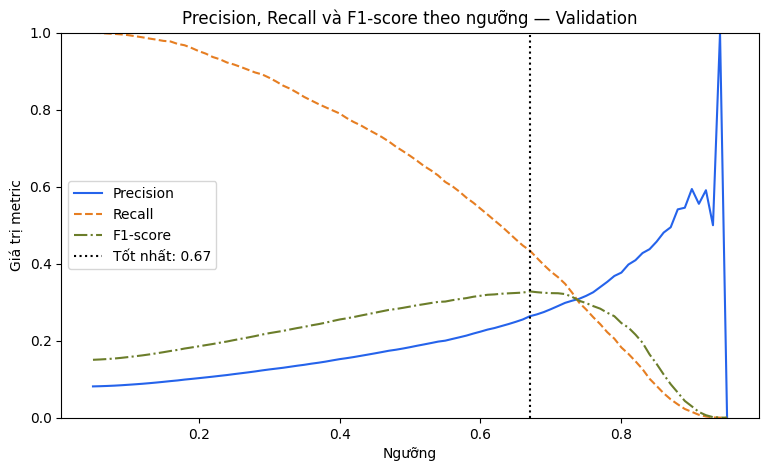

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt

# Vẽ ba metric theo ngưỡng trên tập Validation.
ax = threshold_table.plot(
    x="Ngưỡng", y=["Precision", "Recall", "F1-score"],
    style=["-", "--", "-."], color=["#2563EB", "#E67E22", "#6B7D2A"], figsize=(9, 5),
)
ax.axvline(best_threshold, color="black", linestyle=":", label=f"Tốt nhất: {best_threshold:.2f}")
ax.set(title="Precision, Recall và F1-score theo ngưỡng — Validation", ylabel="Giá trị metric", ylim=(0, 1))
plt.legend()
plt.show()


## VIII. Đánh giá cuối cùng trên tập Test


### 1. Đánh giá tại ngưỡng 0,5


In [28]:
# Dự đoán trên Test tại ngưỡng mặc định 0,5.
test_probabilities = hgb_model.predict_proba(X_test_hgb)[:, 1]
test_predictions_05 = (test_probabilities >= 0.5).astype(int)
assert len(test_predictions_05) == len(y_test)

metrics_05 = {
    "Ngưỡng": 0.5,
    "Precision": precision_score(y_test, test_predictions_05),
    "Recall": recall_score(y_test, test_predictions_05),
    "F1-score": f1_score(y_test, test_predictions_05),
}
display(pd.DataFrame([metrics_05]).round(4))


,Ngưỡng,Precision,Recall,F1-score
0,0.5,0.1839,0.6813,0.2896


**Nhận xét:**

- Tại ngưỡng mặc định `0,5`, mô hình đạt Precision `0,1839`, Recall `0,6813` và F1-score `0,2896`.
- Mô hình phát hiện được khoảng 68,13% khách nợ xấu, nhưng trong các khách bị cảnh báo chỉ khoảng 18,39% thực sự nợ xấu. Vì vậy, ngưỡng `0,5` ưu tiên phát hiện nhiều trường hợp nhưng tạo khá nhiều cảnh báo nhầm.


### 2. Đánh giá tại ngưỡng được chọn từ Validation


In [29]:
# Dùng ngưỡng đã chọn từ Validation.
test_predictions_best = (test_probabilities >= best_threshold).astype(int)

metrics_best = {
    "Ngưỡng": best_threshold,
    "Precision": precision_score(y_test, test_predictions_best),
    "Recall": recall_score(y_test, test_predictions_best),
    "F1-score": f1_score(y_test, test_predictions_best),
}
display(pd.DataFrame([metrics_best]).round(4))


,Ngưỡng,Precision,Recall,F1-score
0,0.67,0.263,0.4396,0.3292


**Nhận xét:**

- Với ngưỡng `0,67` đã chọn từ Validation, Precision tăng lên `0,2630`, Recall giảm còn `0,4396` và F1-score tăng lên `0,3292`.
- Ngưỡng cao hơn yêu cầu mô hình chắc chắn hơn trước khi cảnh báo nợ xấu. Do đó, cảnh báo chính xác hơn nhưng mô hình cũng bỏ sót nhiều khách nợ xấu hơn.


### 3. So sánh hai ngưỡng


In [30]:
# Đặt hai kết quả cạnh nhau để so sánh.
threshold_comparison = pd.DataFrame(
    [metrics_05, metrics_best],
    index=["Ngưỡng 0,5", "Ngưỡng được chọn"],
)
display(threshold_comparison.round(4))


,Ngưỡng,Precision,Recall,F1-score
"Ngưỡng 0,5",0.50,0.1839,0.6813,0.2896
Ngưỡng được chọn,0.67,0.2630,0.4396,0.3292


**Nhận xét:**

- So với ngưỡng `0,5`, ngưỡng `0,67` làm Precision tăng 7,91 điểm phần trăm và F1-score tăng 3,96 điểm phần trăm, nhưng Recall giảm 24,17 điểm phần trăm.
- F1-score Test `0,3292` rất gần F1-score Validation `0,3281`, cho thấy hiệu quả của ngưỡng mới khá ổn định trên dữ liệu chưa dùng để chọn ngưỡng.
- Vì mục tiêu của notebook là tối đa F1-score, ngưỡng `0,67` đạt mục tiêu đề ra. Tuy nhiên, nếu nghiệp vụ ưu tiên hạn chế bỏ sót nợ xấu thì cần cân nhắc thêm sự suy giảm Recall.


### 4. Ma trận nhầm lẫn tại ngưỡng mới


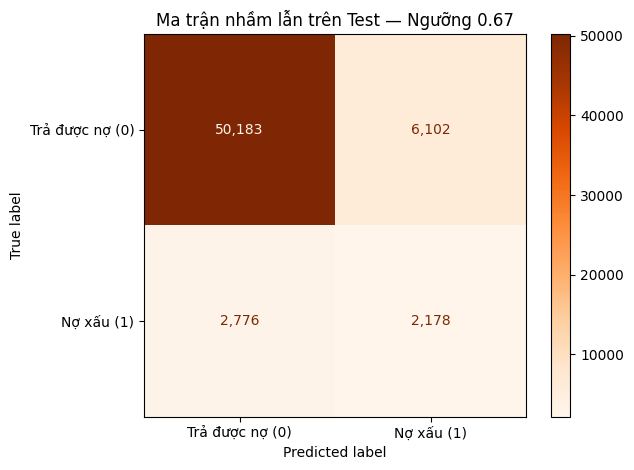

In [31]:
%matplotlib inline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Vẽ ma trận nhầm lẫn tại ngưỡng đã chọn.
test_confusion_matrix = confusion_matrix(y_test, test_predictions_best)
assert test_confusion_matrix.sum() == len(y_test)

ConfusionMatrixDisplay(
    test_confusion_matrix, display_labels=["Trả được nợ (0)", "Nợ xấu (1)"]
).plot(cmap="Oranges", values_format=",d")
plt.title(f"Ma trận nhầm lẫn trên Test — Ngưỡng {best_threshold:.2f}")
plt.tight_layout()
plt.show()


**Nhận xét:**

- Mô hình dự đoán đúng 50.183 khách trả được nợ và phát hiện đúng 2.178 khách nợ xấu.
- Có 6.102 khách trả được nợ bị cảnh báo nhầm và 2.776 khách nợ xấu bị bỏ sót. Tổng bốn ô bằng 61.239 dòng của tập Test.
- Số khách nợ xấu bị bỏ sót lớn hơn số được phát hiện đúng, phù hợp với Recall `0,4396`. Đây là đánh đổi cần nêu rõ khi sử dụng ngưỡng tối ưu theo F1-score.


## IX. Lưu mô hình và kết quả


### 1. Lưu mô hình và thông tin tiền xử lý


In [32]:
import joblib

# Tạo gói gồm mô hình, ngưỡng và thông tin tiền xử lý.
model_package = {
    "model": hgb_model,
    "decision_threshold": best_threshold,
    "feature_names": FEATURE_NAMES,
    "numeric_columns": num_cols.tolist(),
    "categorical_columns": cat_cols.tolist(),
    "train_median": train_median.to_dict(),
    "dropped_interactions": interaction_co_san,
}

MODELS_DIR = env_path.parent / "models"
MODELS_DIR.mkdir(exist_ok=True)
model_path = MODELS_DIR / "hist_gradient_boosting_threshold_optimized.pkl"
joblib.dump(model_package, model_path)

print(f"Đã lưu mô hình: {model_path}")


Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting_threshold_optimized.pkl


### 2. Lưu ngưỡng và Metric


In [33]:
import json
from datetime import datetime

# Lưu thông tin chính của mô hình dưới dạng JSON.
final_metrics = {
    "model_name": "Credit Risk - HistGradientBoosting Threshold Optimized",
    "model_type": type(hgb_model).__name__,
    "model_version": "1.1.0",
    "trained_from": "06_1_threshold_optimization.ipynb",
    "saved_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "features_count": len(FEATURE_NAMES),
    "decision_threshold": round(float(best_threshold), 2),
    "validation_f1_score": round(float(best_threshold_row["F1-score"]), 4),
    "test_precision": round(float(metrics_best["Precision"]), 4),
    "test_recall": round(float(metrics_best["Recall"]), 4),
    "test_f1_score": round(float(metrics_best["F1-score"]), 4),
    "confusion_matrix": test_confusion_matrix.tolist(),
}

metrics_path = MODELS_DIR / "hist_gradient_boosting_threshold_optimized_metrics.json"
metrics_path.write_text(json.dumps(final_metrics, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Đã lưu metric: {metrics_path}")


Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting_threshold_optimized_metrics.json


### 3. Kiểm tra file đã lưu


In [34]:
# Kiểm tra tên, trạng thái và dung lượng hai file mới.
saved_files = pd.DataFrame({
    "File": [model_path.name, metrics_path.name],
    "Tồn tại": [model_path.exists(), metrics_path.exists()],
    "Dung lượng (KB)": [model_path.stat().st_size / 1024, metrics_path.stat().st_size / 1024],
})

assert saved_files["Tồn tại"].all()
display(saved_files.round(1))


,File,Tồn tại,Dung lượng (KB)
0,hist_gradient_boosting_threshold_optimized.pkl,True,677.0
1,hist_gradient_boosting_threshold_optimized_met...,True,0.5


## X. Tổng kết


- Dữ liệu được chia thành Train, Validation và Test theo tỷ lệ xấp xỉ 64/16/20. Sau tiền xử lý, ba tập có cùng 360 feature và không còn giá trị thiếu.
- HistGradientBoosting được huấn luyện trên Train; 91 ngưỡng được đánh giá riêng trên Validation. Ngưỡng `0,67` cho F1-score Validation cao nhất là `0,3281`, đồng thời các ngưỡng lân cận cho kết quả khá gần nhau.
- Trên Test, việc đổi ngưỡng từ `0,5` lên `0,67` làm Precision tăng từ `0,1839` lên `0,2630` và F1-score tăng từ `0,2896` lên `0,3292`; Recall giảm từ `0,6813` xuống `0,4396`. Kết quả Test gần với Validation cho thấy ngưỡng mới tương đối ổn định trên dữ liệu chưa dùng để lựa chọn.
- Tại ngưỡng `0,67`, mô hình phát hiện đúng 2.178 khách nợ xấu nhưng bỏ sót 2.776 khách. Vì vậy, ngưỡng này phù hợp với mục tiêu tối đa F1-score, nhưng cần cân nhắc lại nếu nghiệp vụ ưu tiên hạn chế bỏ sót nợ xấu.
- Mô hình tối ưu ngưỡng và metadata đã được lưu riêng tại `models/hist_gradient_boosting_threshold_optimized.pkl` và `models/hist_gradient_boosting_threshold_optimized_metrics.json`, không ghi đè file của Notebook 06. Hai file này là đầu vào cho Notebook 07.
